# Análise de Perfis Socioeconômicos dos Participantes do ENEM 2024 - Paraíba
## Segunda Etapa: Seleção de Variáveis, Análise de Outliers e Pré-processamento

---

## Contexto

Este notebook é uma **continuação da Primeira Etapa** (`primeira_etapa.ipynb`), onde realizamos o pré-tratamento inicial dos microdados do ENEM 2024 da Paraíba.

**Arquivo anterior:** `primeira_etapa.ipynb`  
**Arquivo gerado na etapa anterior:** `enem_pb_2024_pre_tratado.csv`

---

## Objetivos desta Etapa

Nesta segunda etapa, vamos:

1. **Selecionar as variáveis** mais relevantes para caracterização de perfis socioeconômicos
2. **Realizar análise detalhada de outliers** e validar a plausibilidade de valores extremos
3. **Aplicar transformações adequadas** aos dados (normalização, encoding, padronização)
4. **Preparar os dados finais** para a etapa de clusterização

---

## Metodologia

| Etapa | Descrição | Técnicas Utilizadas |
|-------|-----------|---------------------|
| 1. Seleção de Variáveis | Identificar 19 variáveis relevantes | Análise conceitual (5 dimensões socioeconômicas) |
| 2. Criação de Variáveis Derivadas | Converter categorias em valores numéricos | Mapeamento baseado no dicionário INEP |
| 3. Análise de Outliers | Detectar e investigar valores extremos | Método IQR, análise de consistência |
| 4. Validação de Outliers | Verificar plausibilidade de casos extremos | Análise de renda per capita, correlações |
| 5. Transformação de Variáveis | Normalizar e codificar variáveis | Log-transform, OrdinalEncoder, OneHotEncoder, StandardScaler |
| 6. Pipeline de Pré-processamento | Aplicar transformações de forma consistente | ColumnTransformer, SimpleImputer |
| 7. Validação Final | Garantir integridade dos dados transformados | Verificação de NaN, estatísticas descritivas |

---

## Questão de Pesquisa

**Quais são os perfis socioeconômicos dos participantes do ENEM da Paraíba em 2024?**

Para responder a esta questão, os dados transformados neste notebook serão utilizados na **Terceira Etapa** para aplicação de técnicas de clusterização (K-Means) sobre as variáveis que melhor capturam:

- **Capital Econômico:** Renda familiar, patrimônio (bens materiais)
- **Capital Cultural:** Escolaridade dos pais, tipo de escola
- **Recursos Domiciliares:** Composição familiar, infraestrutura residencial
- **Acesso Tecnológico:** Internet, computadores, recursos digitais
- **Características Demográficas:** Sexo, raça/cor, idade, estado civil

---

In [1]:
# %%
# Dependencias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#from google.colab import drive
import os
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.stats import skew

## 1. Carregamento dos Dados

Nesta seção, vamos carregar o arquivo CSV gerado na **Primeira Etapa**.

**Arquivo esperado:** `enem_pb_2024_pre_tratado.csv`

Este arquivo contém:
-  Dados filtrados da Paraíba
-  Colunas renomeadas
-  Valores ausentes tratados
-  128.546 participantes do ENEM 2024

In [2]:
# %%
# Carregamento dos dados (arquivo local)

caminho_arquivo = "dataset_pre_tratado_enem_pb_2024.csv.gz"

if os.path.exists(caminho_arquivo):
    print(f"Arquivo encontrado: {caminho_arquivo}")
    print(f"Tamanho: {os.path.getsize(caminho_arquivo) / (1024*1024):.2f} MB")
else:
    print(f"Arquivo NAO encontrado: {caminho_arquivo}")

df = pd.read_csv(caminho_arquivo, compression='gzip')
print(f"\nDados carregados: {df.shape[0]} linhas, {df.shape[1]} colunas")

Arquivo encontrado: dataset_pre_tratado_enem_pb_2024.csv.gz
Tamanho: 2.12 MB

Dados carregados: 128546 linhas, 38 colunas


## 1. Seleção de Variáveis

### 1.1 Critérios de Seleção

Para a análise de perfis socioeconômicos, selecionamos variáveis que capturam diferentes dimensões do perfil dos participantes do ENEM 2024 na Paraíba.

As variáveis foram escolhidas com base em cinco dimensões principais:

1. **Capital Cultural** - Educação dos pais como proxy do ambiente educacional familiar
2. **Capital Econômico** - Renda e bens materiais como indicadores de poder aquisitivo
3. **Recursos Domiciliares** - Composição familiar e infraestrutura da residência
4. **Acesso Tecnológico** - Internet, computadores e recursos digitais para educação
5. **Características Demográficas** - Sexo, raça, idade, tipo de escola

---

### 1.2 Variáveis Selecionadas

#### Variáveis Ordinais (2)

Representam níveis hierárquicos de escolaridade dos pais.

| Variável | Descrição | Níveis | Justificativa |
|----------|-----------|--------|---------------|
| `esc_mae` | Escolaridade da mãe | A (Nunca estudou) a G (Pós-graduação) | Escolaridade materna tem forte correlação com desempenho acadêmico dos filhos |
| `esc_pai` | Escolaridade do pai | A (Nunca estudou) a G (Pós-graduação) | Complementa capital cultural familiar |

**Nota:** A categoria H ("Não sei") será tratada como valor ausente e imputada pela moda.

---

#### Variáveis Numéricas Contínuas (4)

Capturam características quantitativas da família e trajetória educacional.

| Variável | Descrição | Range | Justificativa |
|----------|-----------|-------|---------------|
| `renda_numerica` | Renda familiar mensal (R$) | 0 a 35.000 | Principal indicador socioeconômico, será transformada por log |
| `pessoas_residencia` | Número de pessoas na casa | 1 a 20 | Afeta renda per capita e recursos disponíveis |
| `total_bens` | Total de bens e recursos | 0 a 32 | Índice sintético de patrimônio familiar |
| `ano_conclusao` | Ano de conclusão do ensino médio | 2006 a 2024 | Indica recência da formação educacional |

---

#### Variáveis Binárias (3)

Indicam presença ou ausência de características importantes.

| Variável | Descrição | Categorias | Justificativa |
|----------|-----------|------------|---------------|
| `tem_internet_wifi` | Acesso à internet em casa | 0 (Não), 1 (Sim) | Recurso crítico para educação moderna |
| `possui_renda` | Se o participante possui renda própria | 0 (Não), 1 (Sim) | Indica se o jovem trabalha, relevante para perfil socioeconômico |
| `treineiro` | Se faz ENEM como treinamento | 0 (Não), 1 (Sim) | Indica estratégia educacional |

---

#### Variáveis Ordinais Especiais (2)

Variáveis com múltiplos níveis ordenados que serão tratadas separadamente.

| Variável | Descrição | Níveis | Justificativa |
|----------|-----------|--------|---------------|
| `tem_computador_notebook` | Quantidade de computadores | A (0) a E (4 ou mais) | Acesso a tecnologia para estudo, preserva gradação |
| `tem_carro` | Quantidade de carros | A (0) a D (3 ou mais) | Indicador de mobilidade e poder aquisitivo |

---

#### Variáveis Categóricas Nominais (8)

Características demográficas e educacionais sem ordem intrínseca.

| Variável | Descrição | Categorias | Justificativa |
|----------|-----------|------------|---------------|
| `faixa_etaria` | Faixa etária do participante | 1 a 20 (códigos INEP) | Perfil demográfico |
| `sexo` | Sexo biológico | M (Masculino), F (Feminino) | Identificar desigualdades de gênero |
| `estado_civil` | Estado civil | 0 a 4 | Contexto familiar do participante |
| `cor_raca` | Cor/raça autodeclarada | 0 a 6 | Identificar desigualdades raciais |
| `nacionalidade` | Nacionalidade | 0 a 4 | Perfil de origem |
| `status_conclusao` | Status de conclusão do EM | 1 a 4 | Trajetória educacional |
| `tipo_ensino` | Tipo de ensino médio | 1 (Regular), 2 (Especial) | Modalidade educacional |
| `tipo_escola` | Tipo de escola | A a F | Principal indicador socioeconômico educacional |

---

### 1.3 Variáveis Excluídas

**Variáveis de desempenho (serão analisadas posteriormente):**
- `NU_NOTA_CN`, `NU_NOTA_CH`, `NU_NOTA_LC`, `NU_NOTA_MT`, `NU_NOTA_REDACAO`

**Identificadores sem valor preditivo:**
- `NU_INSCRICAO`

**Sem variabilidade (todos os registros da Paraíba):**
- `SG_UF_RESIDENCIA`, `CO_MUNICIPIO_RESIDENCIA`

**Redundantes:**
- Variáveis de localização da prova (todos fazem prova na Paraíba)

---

### 1.4 Resumo

**Total de variáveis selecionadas: 19**

- 2 variáveis ordinais (escolaridade dos pais)
- 4 variáveis numéricas contínuas
- 3 variáveis binárias
- 2 variáveis ordinais especiais (computador, carro)
- 8 variáveis categóricas nominais

Estas variáveis serão transformadas adequadamente antes da clusterização para preservar suas características (ordinalidade, escala, etc.).

---

In [3]:
# Criação de Variáveis Derivadas e Validação

print("="*60)
print("ETAPA 1: CRIAÇÃO DE VARIÁVEIS DERIVADAS")
print("="*60)

# ============================================================
# 1. RENDA_NUMERICA - Conversão de faixas para valores
# ============================================================

print("\n1. Criando variável 'renda_numerica' a partir de 'renda_mensal_familiar'")
print("-" * 60)

# Mapeamento das categorias de renda para ponto médio das faixas (em reais)
mapa_renda = {
    'A': 0,        # Nenhuma renda
    'B': 1412,     # Até R$ 1.412,00
    'C': 1765,     # De R$ 1.412,01 até R$ 2.118,00
    'D': 2471,     # De R$ 2.118,01 até R$ 2.824,00
    'E': 3177,     # De R$ 2.824,01 até R$ 3.530,00
    'F': 3883,     # De R$ 3.530,01 até R$ 4.236,00
    'G': 4942,     # De R$ 4.236,01 até R$ 5.648,00
    'H': 6354,     # De R$ 5.648,01 até R$ 7.060,00
    'I': 7766,     # De R$ 7.060,01 até R$ 8.472,00
    'J': 9178,     # De R$ 8.472,01 até R$ 9.884,00
    'K': 10590,    # De R$ 9.884,01 até R$ 11.296,00
    'L': 12002,    # De R$ 11.296,01 até R$ 12.708,00
    'M': 13414,    # De R$ 12.708,01 até R$ 14.120,00
    'N': 15532,    # De R$ 14.120,01 até R$ 16.944,00
    'O': 19062,    # De R$ 16.944,01 até R$ 21.180,00
    'P': 24710,    # De R$ 21.180,01 até R$ 28.240,00
    'Q': 35000     # Acima de R$ 28.240,00
}

df['renda_numerica'] = df['renda_mensal_familiar'].map(mapa_renda)

print(f"   Valores convertidos: {df['renda_numerica'].notna().sum():,}")
print(f"   Renda mínima: R$ {df['renda_numerica'].min():.2f}")
print(f"   Renda mediana: R$ {df['renda_numerica'].median():.2f}")
print(f"   Renda máxima: R$ {df['renda_numerica'].max():.2f}")

# ============================================================
# 2. TOTAL_BENS - Soma ponderada de bens e recursos
# ============================================================

print("\n2. Criando variável 'total_bens' (índice agregado de patrimônio)")
print("-" * 60)

variaveis_bens = [
    'tem_banheiro', 'tem_quarto', 'tem_carro', 'tem_motocicleta',
    'tem_geladeira', 'tem_freezer', 'tem_maquina_de_lavar',
    'tem_micro_ondas', 'tem_aspirador_de_po', 'tem_tv',
    'tem_tv_por_assinatura', 'tem_internet_wifi',
    'tem_computador_notebook', 'tem_celular'
]

def converter_bem_para_numero(valor):
    """Converte categorias de bens em valores numéricos"""
    if pd.isna(valor):
        return 0
    mapa = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
    return mapa.get(valor, 0)

df['total_bens'] = 0
for bem in variaveis_bens:
    if bem in df.columns:
        df['total_bens'] += df[bem].apply(converter_bem_para_numero)

print(f"   Variáveis de bens utilizadas: {len(variaveis_bens)}")
print(f"   Total de bens mínimo: {df['total_bens'].min()}")
print(f"   Total de bens mediano: {df['total_bens'].median():.0f}")
print(f"   Total de bens máximo: {df['total_bens'].max()}")

# ============================================================
# 3. CONVERSÃO DE VARIÁVEIS BINÁRIAS - A/B para 0/1
# ============================================================

print("\n3. Convertendo variáveis binárias de A/B para 0/1")
print("-" * 60)

# Identificar variáveis binárias
binary_vars = ['tem_internet_wifi', 'possui_renda', 'treineiro']

# Mapeamento A/B para 0/1
mapa_binario = {'A': 0, 'B': 1}

print("\nConversão de categorias:")
for var in binary_vars:
    if var in df.columns:
        # Verificar valores antes da conversão
        valores_antes = df[var].value_counts().sort_index().to_dict()
        
        # Verificar se já está em formato numérico (0/1)
        valores_unicos = set(df[var].dropna().unique())
        if valores_unicos.issubset({0, 1, 0.0, 1.0}):
            # Já está em formato binário, apenas converter para int
            df[var] = df[var].astype('Int64')  # Int64 suporta NaN
            print(f"\n  {var}:")
            print(f"    Já estava em formato 0/1: {valores_antes}")
            print(f"    Mantido: {df[var].notna().sum():,} valores")
            print(f"    Tipo: {df[var].dtype}")
            continue

        # Converter A/B para 0/1
        df[var] = df[var].map(mapa_binario)

        # Verificar após conversão
        valores_depois = df[var].value_counts().sort_index().to_dict()
        n_convertidos = df[var].notna().sum()

        print(f"\n  {var}:")
        print(f"    Antes: {valores_antes}")
        print(f"    Depois: {valores_depois}")
        print(f"    Convertidos: {n_convertidos:,} valores")
        print(f"    Tipo: {df[var].dtype}")

print(f"\nTotal de variáveis binárias convertidas: {len(binary_vars)}")
print("Formato final: 0 (não/ausente) e 1 (sim/presente)")

# ============================================================
# ETAPA 2: DEFINIÇÃO DAS VARIÁVEIS SELECIONADAS
# ============================================================

print("\n" + "="*60)
print("ETAPA 2: DEFINIÇÃO DAS VARIÁVEIS SELECIONADAS")
print("="*60)

ordinal_vars = ['esc_mae', 'esc_pai']

ordinal_especiais_vars = ['tem_computador_notebook', 'tem_carro']

numeric_vars = [
    'renda_numerica',
    'pessoas_residencia',
    'total_bens',
    'ano_conclusao'
]

# Variáveis binárias já convertidas para 0/1
# binary_vars já foi definido acima

categorical_vars = [
    'faixa_etaria',
    'sexo',
    'estado_civil',
    'cor_raca',
    'nacionalidade',
    'status_conclusao',
    'tipo_ensino',
    'tipo_escola'
]

todas_variaveis = (ordinal_vars + ordinal_especiais_vars +
                   numeric_vars + binary_vars + categorical_vars)

print(f"\nTotal de variáveis: {len(todas_variaveis)}")
print(f"  - Ordinais (escolaridade): {len(ordinal_vars)}")
print(f"  - Ordinais especiais (bens): {len(ordinal_especiais_vars)}")
print(f"  - Numéricas contínuas: {len(numeric_vars)}")
print(f"  - Binárias (já convertidas 0/1): {len(binary_vars)}")
print(f"  - Categóricas nominais: {len(categorical_vars)}")

# ============================================================
# ETAPA 3: VALIDAÇÃO DE EXISTÊNCIA
# ============================================================

print("\n" + "="*60)
print("ETAPA 3: VALIDAÇÃO DE EXISTÊNCIA DAS VARIÁVEIS")
print("="*60)

colunas_faltantes = set(todas_variaveis) - set(df.columns)

if colunas_faltantes:
    print(f"\nERRO: {len(colunas_faltantes)} variáveis não encontradas:")
    for col in sorted(colunas_faltantes):
        print(f"  - {col}")
    raise ValueError("Variáveis ausentes no dataset.")
else:
    print(f"\nValidação OK: Todas as {len(todas_variaveis)} variáveis presentes")

# ============================================================
# ETAPA 4: ANÁLISE DE VALORES AUSENTES
# ============================================================

print("\n" + "="*60)
print("ETAPA 4: ANÁLISE DE VALORES AUSENTES")
print("="*60)

missing_info = []
for col in todas_variaveis:
    n_missing = df[col].isnull().sum()
    pct_missing = (n_missing / len(df)) * 100
    if n_missing > 0:
        missing_info.append({
            'Variável': col,
            'Ausentes': n_missing,
            'Percentual': f"{pct_missing:.2f}%"
        })

if missing_info:
    missing_df = pd.DataFrame(missing_info)
    print("\nVariáveis com valores ausentes:")
    display(missing_df)
else:
    print("\nNenhuma variável possui valores ausentes")

# ============================================================
# ETAPA 5: ESTATÍSTICAS DESCRITIVAS
# ============================================================

print("\n" + "="*60)
print("ETAPA 5: ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS")
print("="*60)

display(df[numeric_vars].describe().round(2))

print("\n" + "="*60)
print("DISTRIBUIÇÃO - VARIÁVEIS BINÁRIAS (já convertidas)")
print("="*60)

for var in binary_vars:
    counts = df[var].value_counts().sort_index()
    print(f"\n{var}:")
    for valor, qtd in counts.items():
        pct = (qtd / len(df)) * 100
        rotulo = "Não/Ausente" if valor == 0 else "Sim/Presente"
        print(f"  {int(valor)} ({rotulo}): {qtd:,} ({pct:.2f}%)")

print("\n" + "="*60)
print("CONCLUSÃO DA ETAPA")
print("="*60)
print("""
Variáveis criadas com sucesso:
  ✓ renda_numerica: Conversão de faixas categóricas para valores numéricos
  ✓ total_bens: Índice agregado de patrimônio familiar
  ✓ Binárias: Conversão A/B para 0/1 (tem_internet_wifi, possui_renda, treineiro)

Todas as variáveis estão prontas para as próximas etapas de análise.
""")

ETAPA 1: CRIAÇÃO DE VARIÁVEIS DERIVADAS

1. Criando variável 'renda_numerica' a partir de 'renda_mensal_familiar'
------------------------------------------------------------
   Valores convertidos: 128,546
   Renda mínima: R$ 0.00
   Renda mediana: R$ 1412.00
   Renda máxima: R$ 35000.00

2. Criando variável 'total_bens' (índice agregado de patrimônio)
------------------------------------------------------------
   Variáveis de bens utilizadas: 14
   Total de bens mínimo: 0
   Total de bens mediano: 10
   Total de bens máximo: 32

3. Convertendo variáveis binárias de A/B para 0/1
------------------------------------------------------------

Conversão de categorias:

  tem_internet_wifi:
    Antes: {'A': 18023, 'B': 110523}
    Depois: {0: 18023, 1: 110523}
    Convertidos: 128,546 valores
    Tipo: int64

  possui_renda:
    Antes: {'A': 98404, 'B': 30142}
    Depois: {0: 98404, 1: 30142}
    Convertidos: 128,546 valores
    Tipo: int64

  treineiro:
    Já estava em formato 0/1: {0: 

,renda_numerica,pessoas_residencia,total_bens,ano_conclusao
count,128546.00,128546.00,128546.00,128546.00
mean,2553.13,3.75,10.72,2.70
std,4065.22,1.41,4.64,4.79
min,0.00,1.00,0.00,0.00
25%,1412.00,3.00,8.00,0.00
50%,1412.00,4.00,10.00,0.00
75%,1765.00,4.00,13.00,3.00
max,35000.00,20.00,32.00,18.00



DISTRIBUIÇÃO - VARIÁVEIS BINÁRIAS (já convertidas)

tem_internet_wifi:
  0 (Não/Ausente): 18,023 (14.02%)
  1 (Sim/Presente): 110,523 (85.98%)

possui_renda:
  0 (Não/Ausente): 98,404 (76.55%)
  1 (Sim/Presente): 30,142 (23.45%)

treineiro:
  0 (Não/Ausente): 102,320 (79.60%)
  1 (Sim/Presente): 26,226 (20.40%)

CONCLUSÃO DA ETAPA

Variáveis criadas com sucesso:
  ✓ renda_numerica: Conversão de faixas categóricas para valores numéricos
  ✓ total_bens: Índice agregado de patrimônio familiar
  ✓ Binárias: Conversão A/B para 0/1 (tem_internet_wifi, possui_renda, treineiro)

Todas as variáveis estão prontas para as próximas etapas de análise.



## 2. Análise Exploratória e Detecção de Outliers

### 2.1 Objetivos da Análise de Outliers

A detecção e análise de outliers é uma etapa crítica no pré-processamento de dados socioeconômicos. Valores extremos podem representar:

1. **Casos legítimos:** Extrema pobreza ou riqueza real na população
2. **Erros de digitação:** Valores impossíveis ou inconsistentes
3. **Respostas aleatórias:** Participantes que não responderam com seriedade

Nesta seção, utilizaremos o método IQR (Interquartile Range) para detectar outliers e investigaremos sua plausibilidade antes de tomar decisões de tratamento.

---

### 2.2 Método de Detecção: IQR (Interquartile Range)

O método IQR define outliers como valores que estão além dos limites:

- **Limite inferior:** Q1 - 1.5 × IQR
- **Limite superior:** Q3 + 1.5 × IQR

Onde:
- Q1 = Percentil 25
- Q3 = Percentil 75
- IQR = Q3 - Q1

Este método é robusto e amplamente utilizado em análises estatísticas.

---

### 2.3 Variáveis a Serem Analisadas

Focaremos nas variáveis numéricas contínuas, pois são as mais suscetíveis a outliers:

1. **renda_numerica:** Renda familiar mensal em reais
2. **pessoas_residencia:** Número de pessoas na residência
3. **total_bens:** Índice agregado de patrimônio familiar

As demais variáveis (binárias, ordinais e categóricas) têm valores restritos por natureza e não requerem análise de outliers.

---

### 2.4 Estratégia de Investigação

Para cada variável com outliers detectados:

1. Calcular estatísticas descritivas (min, mediana, max, percentual de outliers)
2. Visualizar distribuição através de boxplots
3. Investigar casos extremos individualmente
4. Analisar consistência com outras variáveis (renda per capita, bens per capita)
5. Decidir tratamento baseado em evidências

**Decisão de tratamento será baseada em:**
- Plausibilidade dos valores
- Consistência com contexto socioeconômico da Paraíba
- Impacto na análise subsequente

---

DETECÇÃO DE OUTLIERS - MÉTODO IQR

Estatísticas e Detecção de Outliers:

renda_numerica:
  Min: 0 | Q1: 1412 | Mediana: 1412 | Q3: 1765 | Max: 35000
  Outliers detectados: 38.83%

pessoas_residencia:
  Min: 1 | Q1: 3 | Mediana: 4 | Q3: 4 | Max: 20
  Outliers detectados: 12.02%

total_bens:
  Min: 0 | Q1: 8 | Mediana: 10 | Q3: 13 | Max: 32
  Outliers detectados: 4.61%

VISUALIZAÇÃO: BOXPLOTS DAS VARIÁVEIS


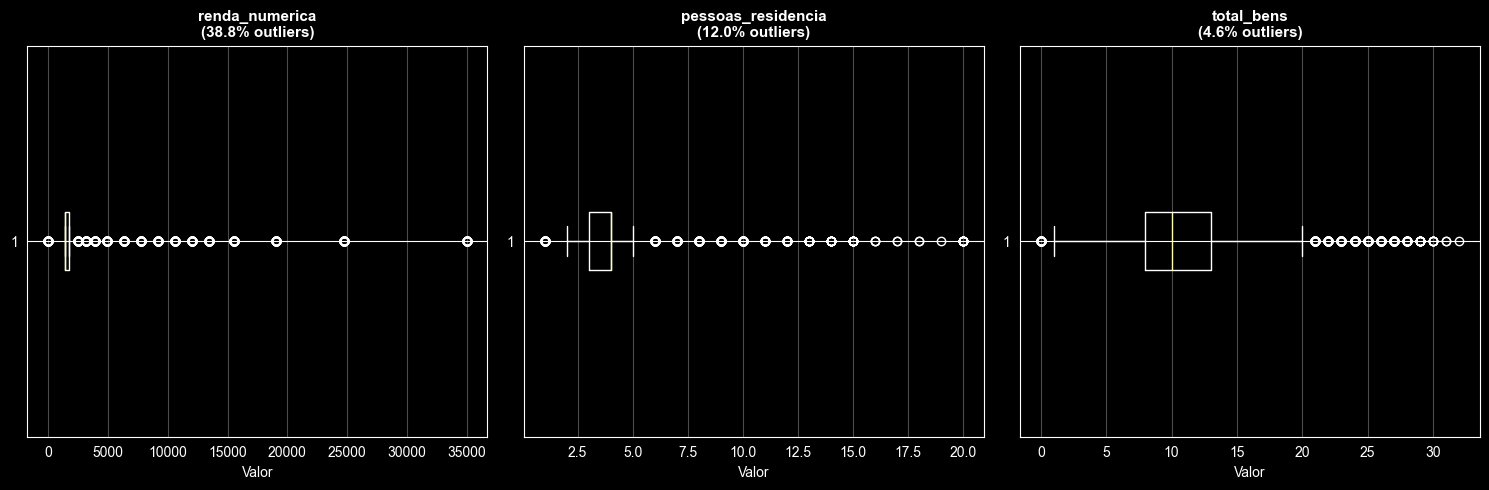

RESUMO DA DETECÇÃO DE OUTLIERS


,Variável,Min,Mediana,Max,Outliers (%)
0,renda_numerica,0,1412.0,35000,38.83
1,pessoas_residencia,1,4.0,20,12.02
2,total_bens,0,10.0,32,4.61



INTERPRETAÇÃO PRELIMINAR
renda_numerica: ALTO - Requer investigação detalhada
pessoas_residencia: ALTO - Requer investigação detalhada
total_bens: BAIXO - Valores extremos provavelmente legítimos


In [4]:
# Detecção de Outliers - Método IQR

def iqr_outliers(series, k=1.5):
    """
    Calcula o percentual de outliers usando o método IQR.

    Parâmetros:
    -----------
    series : pd.Series
        Série de dados a ser analisada
    k : float
        Multiplicador do IQR (padrão: 1.5)

    Retorna:
    --------
    float : Percentual de outliers
    """
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - k * iqr
    limite_superior = q3 + k * iqr
    outliers = ((s < limite_inferior) | (s > limite_superior)).sum()
    return (outliers / len(s)) * 100

print("DETECÇÃO DE OUTLIERS - MÉTODO IQR")

vars_analise = ['renda_numerica', 'pessoas_residencia', 'total_bens']

print("\nEstatísticas e Detecção de Outliers:")

resultados_outliers = []

for col in vars_analise:
    s = df[col].dropna()

    # Estatísticas descritivas
    minimo = s.min()
    mediana = s.median()
    maximo = s.max()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)

    # Detecção de outliers
    pct_outliers = iqr_outliers(df[col])

    print(f"\n{col}:")
    print(f"  Min: {minimo:.0f} | Q1: {q1:.0f} | Mediana: {mediana:.0f} | Q3: {q3:.0f} | Max: {maximo:.0f}")
    print(f"  Outliers detectados: {pct_outliers:.2f}%")

    resultados_outliers.append({
        'Variável': col,
        'Min': minimo,
        'Mediana': mediana,
        'Max': maximo,
        'Outliers (%)': f"{pct_outliers:.2f}"
    })

# Visualização: Boxplots
print("\n" + "="*60)
print("VISUALIZAÇÃO: BOXPLOTS DAS VARIÁVEIS")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(vars_analise):
    axes[i].boxplot(df[col].dropna(), vert=False)
    axes[i].set_xlabel('Valor')
    axes[i].set_title(f'{col}\n({iqr_outliers(df[col]):.1f}% outliers)',
                      fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Resumo em tabela
print("RESUMO DA DETECÇÃO DE OUTLIERS")

resumo_df = pd.DataFrame(resultados_outliers)
display(resumo_df)

print("\n" + "="*60)
print("INTERPRETAÇÃO PRELIMINAR")
print("="*60)

for col in vars_analise:
    pct = iqr_outliers(df[col])
    if pct > 10:
        status = "ALTO - Requer investigação detalhada"
    elif pct > 5:
        status = "MODERADO - Investigar casos extremos"
    else:
        status = "BAIXO - Valores extremos provavelmente legítimos"

    print(f"{col}: {status}")

In [5]:
#Investigação Detalhada de Casos Extremos

print("INVESTIGAÇÃO DE CASOS EXTREMOS")

# ============================================================
# PARTE 1: ANÁLISE DE pessoas_residencia
# ============================================================

print("PARTE 1: ANÁLISE DE pessoas_residencia")

# Examinar os 15 casos com mais pessoas
print("\nTop 15 residências com mais pessoas:")

top_casos = df.nlargest(15, 'pessoas_residencia')[
    ['pessoas_residencia', 'renda_numerica', 'total_bens', 'possui_renda']
].reset_index(drop=True)

display(top_casos)

# Estatísticas dos casos extremos
print("\nDistribuição de casos por limites:")
print("-" * 60)

for limite in [8, 10, 12, 15, 18]:
    qtd = (df['pessoas_residencia'] > limite).sum()
    pct = qtd / len(df) * 100
    print(f"  > {limite} pessoas: {qtd:,} casos ({pct:.2f}%)")

# Distribuição completa dos valores altos
print("\nDistribuição completa (valores acima de 8 pessoas):")
print("-" * 60)

freq_altos = df[df['pessoas_residencia'] > 8]['pessoas_residencia'].value_counts().sort_index()
display(freq_altos.to_frame(name='Quantidade').reset_index().rename(columns={'index': 'pessoas_residencia'}))

INVESTIGAÇÃO DE CASOS EXTREMOS
PARTE 1: ANÁLISE DE pessoas_residencia

Top 15 residências com mais pessoas:


,pessoas_residencia,renda_numerica,total_bens,possui_renda
0,20,1412,1,0
1,20,0,4,0
2,20,0,2,0
3,20,0,4,0
4,20,1412,1,0
5,20,0,2,0
6,20,0,14,1
7,20,1412,23,1
8,20,0,0,0
9,20,0,2,0



Distribuição de casos por limites:
------------------------------------------------------------
  > 8 pessoas: 763 casos (0.59%)
  > 10 pessoas: 181 casos (0.14%)
  > 12 pessoas: 74 casos (0.06%)
  > 15 pessoas: 26 casos (0.02%)
  > 18 pessoas: 19 casos (0.01%)

Distribuição completa (valores acima de 8 pessoas):
------------------------------------------------------------


,pessoas_residencia,Quantidade
0,9,342
1,10,240
2,11,53
3,12,54
4,13,20
5,14,13
6,15,15
7,16,3
8,17,2
9,18,2


In [6]:
# ============================================================
# PARTE 2: ANÁLISE DE CONSISTÊNCIA
# ============================================================

print("\n" + "="*60)
print("PARTE 2: ANÁLISE DE CONSISTÊNCIA")
print("="*60)

# Calcular renda per capita e bens per capita
df['renda_per_capita'] = df['renda_numerica'] / df['pessoas_residencia']
df['bens_per_capita'] = df['total_bens'] / df['pessoas_residencia']

# Analisar casos suspeitos (>10 pessoas E renda < 3000)
casos_suspeitos = df[(df['pessoas_residencia'] > 10) & (df['renda_numerica'] < 3000)]

print(f"\nCASOS SUSPEITOS (>10 pessoas E renda < 3000):")
print(f"\nTotal de casos suspeitos: {len(casos_suspeitos):,}")

# Comparação de renda per capita
print("\n" + "="*60)
print("COMPARAÇÃO: Renda per capita")
print("="*60)

renda_pc_geral = df['renda_per_capita'].mean()
renda_pc_grandes = df[df['pessoas_residencia'] > 10]['renda_per_capita'].mean()
renda_pc_normais = df[df['pessoas_residencia'] <= 10]['renda_per_capita'].mean()

print(f"\n  Geral (todas residências): R$ {renda_pc_geral:.2f}")
print(f"  Residências >10 pessoas: R$ {renda_pc_grandes:.2f}")
print(f"  Residências <=10 pessoas: R$ {renda_pc_normais:.2f}")

razao = renda_pc_normais / renda_pc_grandes
print(f"\n  Razão (normais/grandes): {razao:.2f}x")

if razao > 3:
    print("\n  Interpretação: Famílias grandes têm renda per capita significativamente")
    print("  menor, indicando situação de pobreza. Casos são PLAUSÍVEIS.")
else:
    print("\n  Interpretação: Diferença moderada. Investigação adicional necessária.")


PARTE 2: ANÁLISE DE CONSISTÊNCIA

CASOS SUSPEITOS (>10 pessoas E renda < 3000):

Total de casos suspeitos: 164

COMPARAÇÃO: Renda per capita

  Geral (todas residências): R$ 753.24
  Residências >10 pessoas: R$ 111.42
  Residências <=10 pessoas: R$ 754.14

  Razão (normais/grandes): 6.77x

  Interpretação: Famílias grandes têm renda per capita significativamente
  menor, indicando situação de pobreza. Casos são PLAUSÍVEIS.


In [7]:

# ============================================================
# PARTE 3: ANÁLISE DE renda_numerica
# ============================================================

print("\n" + "="*60)
print("PARTE 3: ANÁLISE DE renda_numerica")
print("="*60)

# Casos com renda muito alta
casos_renda_alta = df[df['renda_numerica'] > 20000]

print(f"\nCasos com renda > R$ 20.000:")
print(f"  Total: {len(casos_renda_alta):,} casos ({len(casos_renda_alta)/len(df)*100:.2f}%)")
print(f"  Renda média deste grupo: R$ {casos_renda_alta['renda_numerica'].mean():,.2f}")
print(f"  Total de bens médio: {casos_renda_alta['total_bens'].mean():.1f}")

# Casos com renda zero
casos_renda_zero = df[df['renda_numerica'] == 0]

print(f"\nCasos com renda = R$ 0:")
print(f"  Total: {len(casos_renda_zero):,} casos ({len(casos_renda_zero)/len(df)*100:.2f}%)")
print(f"  Total de bens médio: {casos_renda_zero['total_bens'].mean():.1f}")


PARTE 3: ANÁLISE DE renda_numerica

Casos com renda > R$ 20.000:
  Total: 1,410 casos (1.10%)
  Renda média deste grupo: R$ 30,825.62
  Total de bens médio: 22.8

Casos com renda = R$ 0:
  Total: 18,810 casos (14.63%)
  Total de bens médio: 7.1



PARTE 1: Matriz de Correlação
------------------------------------------------------------

Matriz de Correlação:


,pessoas_residencia,renda_numerica,total_bens
pessoas_residencia,1.000,0.048,0.126
renda_numerica,0.048,1.000,0.617
total_bens,0.126,0.617,1.000



Interpretação:
  - pessoas_residencia vs renda_numerica: r = 0.048
    Correlação muito fraca (quase zero) - validação de independência

  - pessoas_residencia vs total_bens: r = 0.126
    Correlação fraca - leve tendência de mais pessoas = mais bens

  - renda_numerica vs total_bens: r = 0.617
    Correlação forte - principal eixo socioeconômico

PARTE 2: Scatter Plots


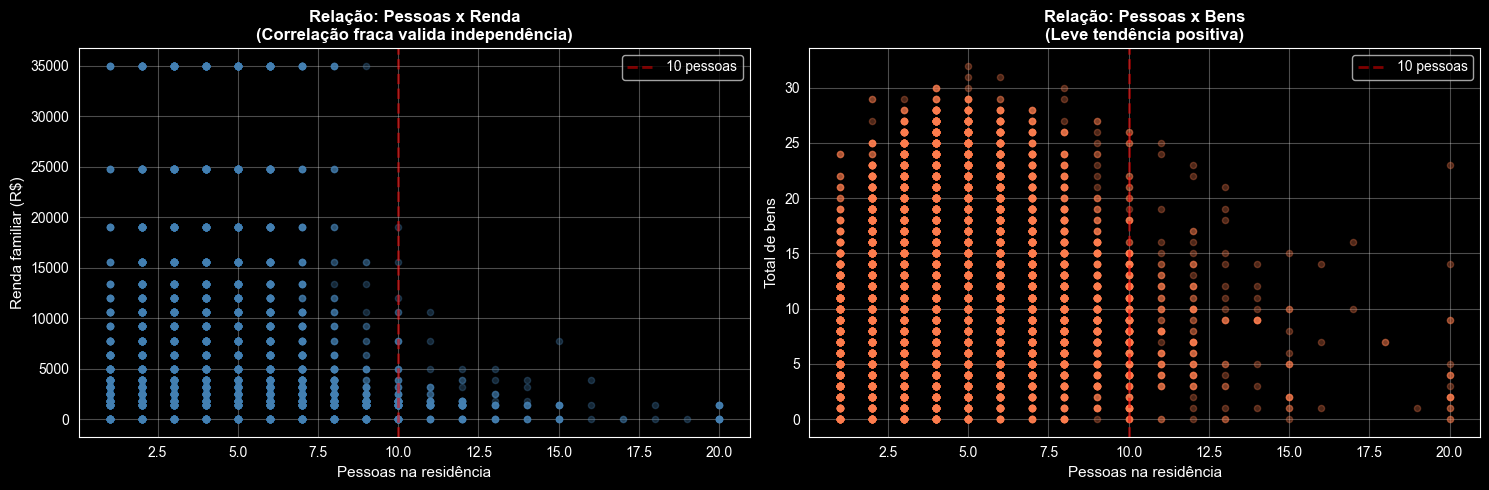


PARTE 3: Distribuição de Frequência


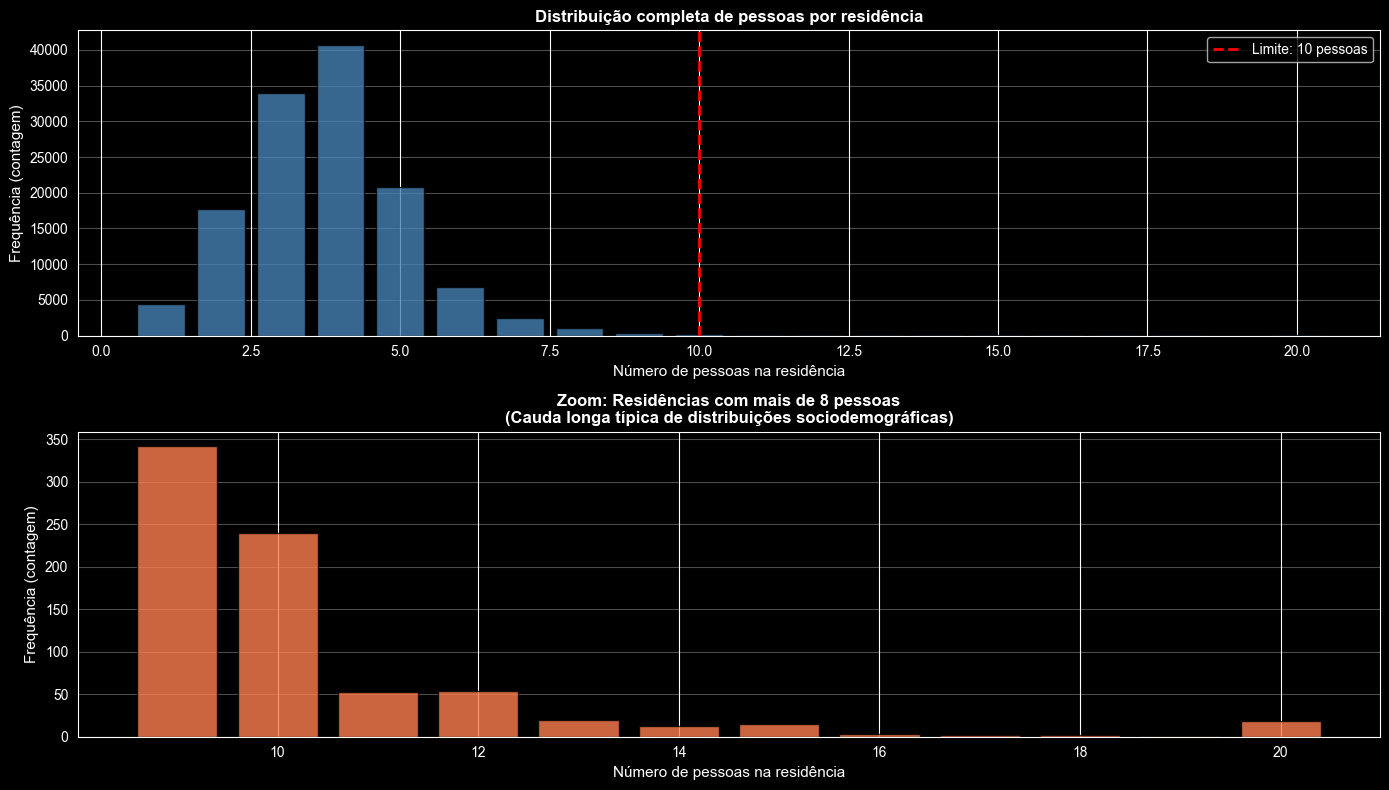


Frequência detalhada (valores > 8):
------------------------------------------------------------


,pessoas_residencia,Quantidade
0,9,342
1,10,240
2,11,53
3,12,54
4,13,20
5,14,13
6,15,15
7,16,3
8,17,2
9,18,2


In [8]:
# Visualização de Correlações e Distribuições
# ============================================================
# PARTE 1: CORRELAÇÕES ENTRE VARIÁVEIS
# ============================================================

print("\nPARTE 1: Matriz de Correlação")
print("-" * 60)

# Calcular correlações
vars_correlacao = ['pessoas_residencia', 'renda_numerica', 'total_bens']
matriz_corr = df[vars_correlacao].corr()

print("\nMatriz de Correlação:")
display(matriz_corr.round(3))

print("\nInterpretação:")
print(f"  - pessoas_residencia vs renda_numerica: r = {matriz_corr.loc['pessoas_residencia', 'renda_numerica']:.3f}")
print("    Correlação muito fraca (quase zero) - validação de independência")
print(f"\n  - pessoas_residencia vs total_bens: r = {matriz_corr.loc['pessoas_residencia', 'total_bens']:.3f}")
print("    Correlação fraca - leve tendência de mais pessoas = mais bens")
print(f"\n  - renda_numerica vs total_bens: r = {matriz_corr.loc['renda_numerica', 'total_bens']:.3f}")
print("    Correlação forte - principal eixo socioeconômico")

# ============================================================
# PARTE 2: SCATTER PLOTS - PESSOAS vs RENDA/BENS
# ============================================================

print("\n" + "="*60)
print("PARTE 2: Scatter Plots")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Pessoas vs Renda
axes[0].scatter(df['pessoas_residencia'], df['renda_numerica'],
                alpha=0.3, s=20, color='steelblue')
axes[0].axvline(x=10, color='red', linestyle='--', alpha=0.5,
                linewidth=2, label='10 pessoas')
axes[0].set_xlabel('Pessoas na residência', fontsize=11)
axes[0].set_ylabel('Renda familiar (R$)', fontsize=11)
axes[0].set_title('Relação: Pessoas x Renda\n(Correlação fraca valida independência)',
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Pessoas vs Total de Bens
axes[1].scatter(df['pessoas_residencia'], df['total_bens'],
                alpha=0.3, s=20, color='coral')
axes[1].axvline(x=10, color='red', linestyle='--', alpha=0.5,
                linewidth=2, label='10 pessoas')
axes[1].set_xlabel('Pessoas na residência', fontsize=11)
axes[1].set_ylabel('Total de bens', fontsize=11)
axes[1].set_title('Relação: Pessoas x Bens\n(Leve tendência positiva)',
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# PARTE 3: DISTRIBUIÇÃO DE FREQUÊNCIA - pessoas_residencia
# ============================================================

print("\n" + "="*60)
print("PARTE 3: Distribuição de Frequência")
print("="*60)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Gráfico 1: Distribuição completa
freq_completa = df['pessoas_residencia'].value_counts().sort_index()
axes[0].bar(freq_completa.index, freq_completa.values,
            color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(x=10, color='red', linestyle='--', linewidth=2,
                label='Limite: 10 pessoas')
axes[0].set_xlabel('Número de pessoas na residência', fontsize=11)
axes[0].set_ylabel('Frequência (contagem)', fontsize=11)
axes[0].set_title('Distribuição completa de pessoas por residência',
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Gráfico 2: Zoom nos valores altos (>8 pessoas)
freq_altos = freq_completa[freq_completa.index > 8]
axes[1].bar(freq_altos.index, freq_altos.values,
            color='coral', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Número de pessoas na residência', fontsize=11)
axes[1].set_ylabel('Frequência (contagem)', fontsize=11)
axes[1].set_title('Zoom: Residências com mais de 8 pessoas\n(Cauda longa típica de distribuições sociodemográficas)',
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Tabela de frequência
print("\nFrequência detalhada (valores > 8):")
print("-" * 60)
display(freq_altos.to_frame(name='Quantidade').reset_index().rename(columns={'index': 'pessoas_residencia'}))

## Decisão Final sobre Tratamento de Outliers

### Síntese da Análise

Após investigação detalhada utilizando múltiplas abordagens (método IQR, análise de consistência, visualizações e correlações), chegamos às seguintes conclusões sobre os outliers detectados:

---

### Variável: renda_numerica

**Outliers detectados:** 38.83% (método IQR)

**Análise:**
- Outliers incluem extrema pobreza (R$ 0 - 14,63% dos casos) e alta renda (>R$ 20.000 - 1,10% dos casos)
- Representa desigualdade socioeconômica real da Paraíba
- Correlação forte com total_bens (r = 0.617) valida consistência dos dados

**Decisão:** MANTER todos os casos

**Justificativa:**
- Desigualdade de renda é característica real da população
- Transformação logarítmica (próxima etapa) reduzirá impacto da assimetria
- Remoção distorceria perfis socioeconômicos reais

---

### Variável: pessoas_residencia

**Outliers detectados:** 12.02% (método IQR)

**Análise:**
- Casos extremos (>10 pessoas) representam 0.14% do dataset
- Renda per capita 6.77x menor em famílias grandes (R$ 111 vs R$ 754)
- Correlação nula com renda (r = 0.048) confirma independência
- Padrão consistente: famílias numerosas em situação de pobreza

**Decisão:** MANTER todos os casos

**Justificativa:**
- Casos são plausíveis e consistentes com contexto do Nordeste brasileiro
- Famílias estendidas multigeracionais são comuns em áreas rurais
- Representam grupo vulnerável relevante para políticas públicas
- Total de 763 casos (0.59%) tem impacto mínimo na clusterização

---

### Variável: total_bens

**Outliers detectados:** 4.61% (método IQR)

**Análise:**
- Percentual baixo de outliers
- Valores máximos (até 32 bens) são plausíveis para classe alta
- Correlação forte com renda (r = 0.617) valida consistência

**Decisão:** MANTER todos os casos

**Justificativa:**
- Apenas 4.61% de outliers (abaixo do limiar de preocupação)
- Valores extremos representam perfil socioeconômico alto legítimo
- Remoção causaria perda desnecessária de informação

---

### Validação por Correlações

A matriz de correlação confirma a legitimidade dos outliers:

| Relação | Correlação | Interpretação |
|---------|------------|---------------|
| pessoas vs renda | r = 0.048 | Independência valida famílias grandes pobres |
| pessoas vs bens | r = 0.126 | Relação fraca e não determinística |
| renda vs bens | r = 0.617 | Forte coerência no eixo socioeconômico |

---

### Estratégia Adotada

**Nenhum outlier será removido ou winsorizado.**

Em vez disso, utilizaremos as seguintes técnicas para lidar com valores extremos:

1. **Transformação logarítmica** em renda_numerica para reduzir assimetria
2. **Normalização** através de StandardScaler para equalizar escalas


Esta abordagem preserva a realidade dos dados enquanto mitiga o impacto de valores extremos na análise de distâncias do algoritmo de clusterização.

---

### Implicações para Clusterização

Manter os outliers permitirá:
- Identificar clusters de extrema pobreza (famílias numerosas, renda zero)
- Identificar clusters de alta renda (classe alta urbana)
- Capturar toda a diversidade socioeconômica da Paraíba
- Gerar insights relevantes para políticas públicas direcionadas

---

## 3. Transformação de Variáveis

### 3.1 Objetivos das Transformações

Antes de aplicar algoritmos de clusterização baseados em distâncias, é necessário transformar as variáveis para garantir:

1. **Normalidade das distribuições:** Reduzir assimetria em variáveis numéricas
2. **Escalas comparáveis:** Padronizar variáveis para mesma magnitude
3. **Representação adequada:** Converter categorias em formato numérico preservando características

---

### 3.2 Transformações Planejadas

#### 3.2.1 Transformação de Assimetria

**Variável:** renda_numerica

**Problema:** Distribuição altamente assimétrica (presença de valores extremos)

**Solução:** Transformação logarítmica

A transformação logarítmica é amplamente utilizada para variáveis de renda por:
- Reduzir impacto de valores extremos
- Aproximar distribuição da normalidade
- Manter interpretabilidade (diferenças proporcionais)

**Fórmula aplicada:** `renda_log = log(renda_numerica + 1)`

O termo "+1" evita problemas com valores zero (log(0) é indefinido).

---

#### 3.2.2 Encoding de Variáveis Ordinais

**Variáveis:** esc_mae, esc_pai

**Método:** OrdinalEncoder

**Justificativa:** Preserva a ordem natural dos níveis de escolaridade (A < B < C ... < G)

**Tratamento de missing:** Categoria H ("Não sei") será substituída por NaN e imputada pela moda

---

#### 3.2.3 Encoding de Variáveis Ordinais Especiais

**Variáveis:** tem_computador_notebook, tem_carro

**Método:** OrdinalEncoder

**Justificativa:** Preserva gradação de quantidade (0, 1, 2, 3, 4+ unidades)

Estas variáveis já estão codificadas como A, B, C, D, E no dataset e serão convertidas para 0, 1, 2, 3, 4.

---

#### 3.2.4 Normalização de Variáveis Numéricas

**Variáveis:** renda_log, pessoas_residencia, total_bens, ano_conclusao

**Método:** StandardScaler (Z-score normalization)

**Fórmula:** `z = (x - média) / desvio_padrão`

**Resultado:** Variáveis com média = 0 e desvio padrão = 1

**Justificativa:** Garante que todas as variáveis tenham mesma escala no cálculo de distâncias euclidianas.

---

#### 3.2.5 Variáveis Binárias

**Variáveis:** tem_internet_wifi, possui_renda, treineiro

**Tratamento:** Manter como 0/1 (já estão em escala adequada)

**Justificativa:** Variáveis binárias já estão naturalmente normalizadas entre 0 e 1, não requerendo transformação adicional.

---

#### 3.2.6 Encoding de Variáveis Categóricas Nominais

**Variáveis:** faixa_etaria, sexo, estado_civil, cor_raca, nacionalidade, status_conclusao, tipo_ensino, tipo_escola

**Método:** OneHotEncoder (criação de variáveis dummy)

**Parâmetro:** `drop='first'` para evitar multicolinearidade (dummy trap)

**Justificativa:** Variáveis nominais não possuem ordem natural, portanto cada categoria se torna uma variável binária independente.

---

### 3.3 Pipeline de Pré-processamento

Utilizaremos `ColumnTransformer` do scikit-learn para aplicar transformações específicas a cada tipo de variável em um único pipeline:
```
ColumnTransformer:
├── OrdinalEncoder → [esc_mae, esc_pai]
├── OrdinalEncoder → [tem_computador_notebook, tem_carro]
├── StandardScaler → [renda_log, pessoas_residencia, total_bens, ano_conclusao]
├── Passthrough → [tem_internet_wifi, possui_renda, treineiro]
└── OneHotEncoder → [faixa_etaria, sexo, estado_civil, cor_raca, ...]
```

**Vantagens do pipeline:**
- Garante aplicação consistente das transformações
- Evita data leakage (fit apenas em dados de treino)
- Facilita reprodução da análise




TRANSFORMAÇÃO DA RENDA - ANÁLISE DE SKEWNESS

CONCEITO: SKEWNESS (ASSIMETRIA)
------------------------------------------------------------

Skewness mede o grau de assimetria de uma distribuição em relação 
à sua média. É calculada pelo terceiro momento padronizado:

    Skewness = E[(X - μ)³] / σ³

Onde:
  - μ = média da distribuição
  - σ = desvio padrão
  - O numerador é o terceiro momento central (diferenças ao cubo)

Por que elevar ao cubo?
  - Preserva o sinal (diferente do quadrado usado na variância)
  - Valores acima da média contribuem positivamente
  - Valores abaixo da média contribuem negativamente

INTERPRETAÇÃO DOS VALORES:
  |  Valor    |  Significado                              |
  |-----------|-------------------------------------------|
  |  = 0      |  Distribuição simétrica (normal)          |
  |  > 0      |  Cauda à direita (valores altos puxam)    |
  |  < 0      |  Cauda à esquerda (valores baixos puxam)  |
  | |s| < 0.5 |  Aproximadamente simétrica           

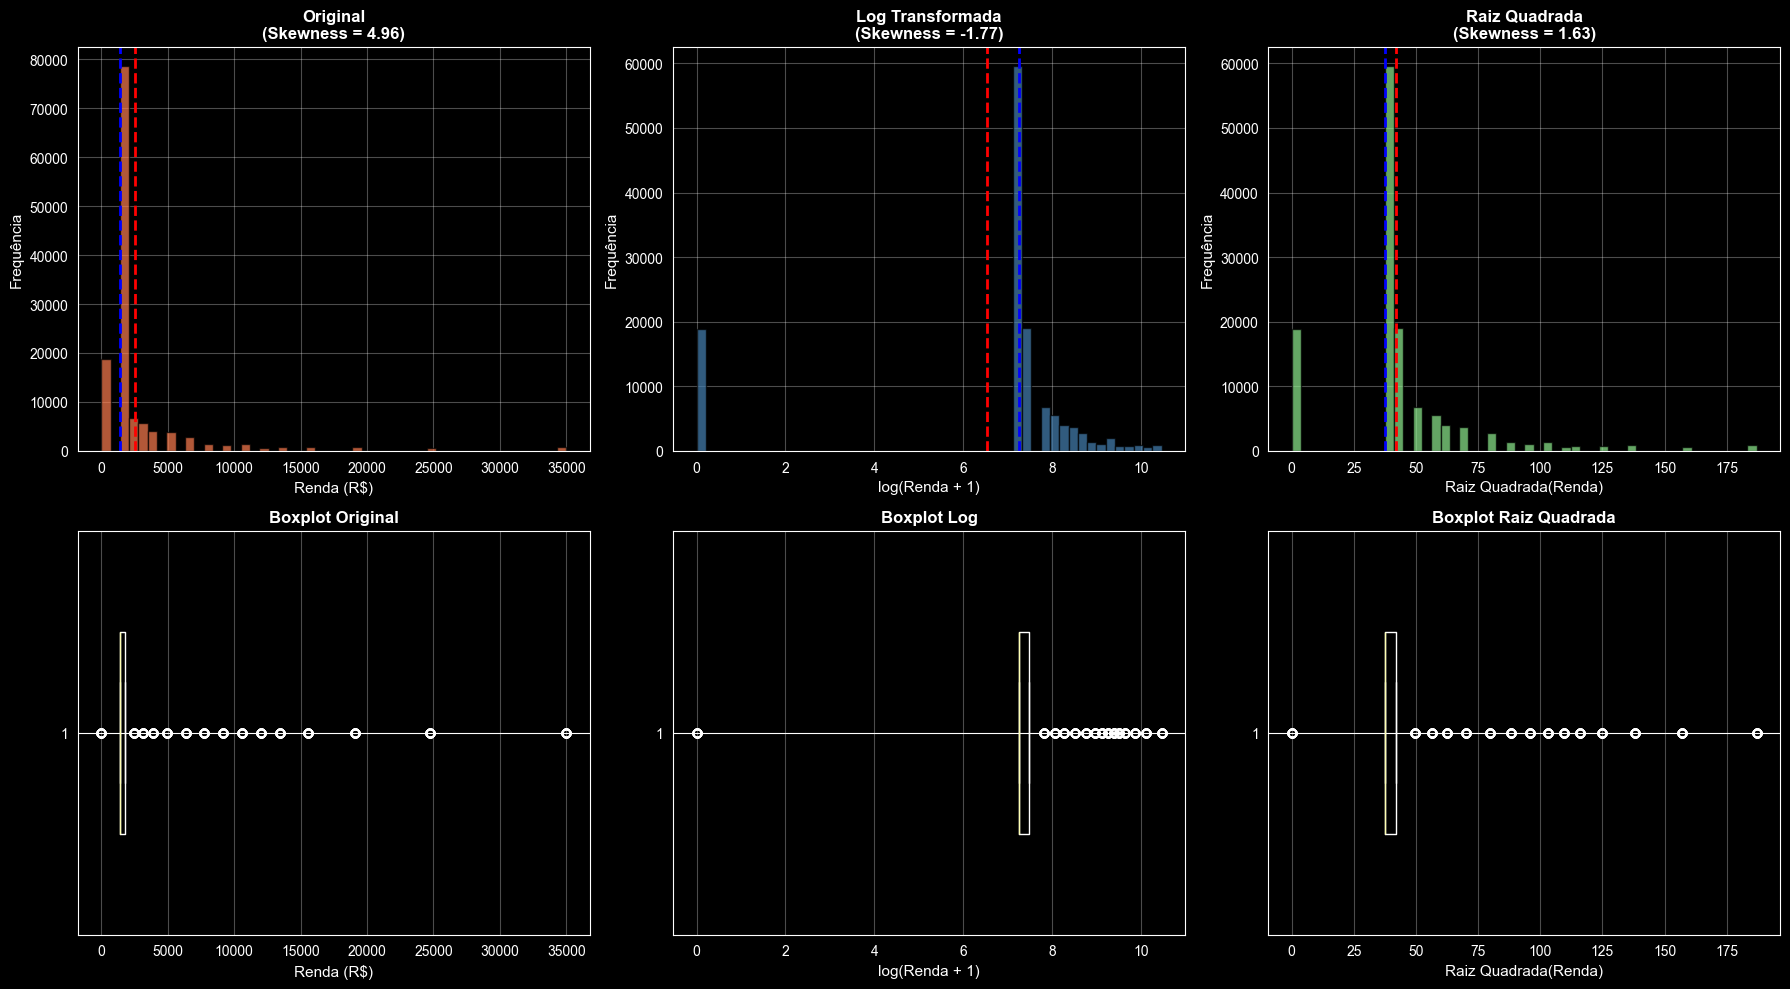


CONCLUSÃO E DECISÃO FINAL

COMPARAÇÃO FINAL:
------------------------------------------------------------
                        Log(x+1)        Raiz Quadrada
  Skewness:             -1.77            1.63
  |Skewness|:           1.77             1.63
  Direção:              Esquerda        Direita
------------------------------------------------------------

DECISÃO: TRANSFORMAÇÃO LOGARÍTMICA (log+1)

JUSTIFICATIVA:

  1. ALTA PROPORÇÃO DE RENDA ZERO (14.63%):
     - Com 18,810 casos de renda zero, é fundamental que a
       transformação SEPARE ADEQUADAMENTE os diferentes níveis de
       baixa renda (R$ 0, R$ 100, R$ 500, etc.)
     - A transformação log proporciona MAIOR SEPARAÇÃO nos valores
       baixos, o que é essencial para identificar perfis de pobreza

  2. CONTEXTO DA CLUSTERIZAÇÃO:
     - O objetivo é identificar perfis socioeconômicos distintos
     - A distinção entre "sem renda" e "baixa renda" é tão importante
       quanto a distinção entre "média" e "alta" renda
  

In [9]:
# Transformação da Renda - Análise de Skewness

import numpy as np
from scipy.stats import skew

print("="*60)
print("TRANSFORMAÇÃO DA RENDA - ANÁLISE DE SKEWNESS")
print("="*60)

# ============================================================
# CONCEITO: O QUE É SKEWNESS (ASSIMETRIA)?
# ============================================================

print("""
CONCEITO: SKEWNESS (ASSIMETRIA)
------------------------------------------------------------

Skewness mede o grau de assimetria de uma distribuição em relação 
à sua média. É calculada pelo terceiro momento padronizado:

    Skewness = E[(X - μ)³] / σ³

Onde:
  - μ = média da distribuição
  - σ = desvio padrão
  - O numerador é o terceiro momento central (diferenças ao cubo)

Por que elevar ao cubo?
  - Preserva o sinal (diferente do quadrado usado na variância)
  - Valores acima da média contribuem positivamente
  - Valores abaixo da média contribuem negativamente

INTERPRETAÇÃO DOS VALORES:
  |  Valor    |  Significado                              |
  |-----------|-------------------------------------------|
  |  = 0      |  Distribuição simétrica (normal)          |
  |  > 0      |  Cauda à direita (valores altos puxam)    |
  |  < 0      |  Cauda à esquerda (valores baixos puxam)  |
  | |s| < 0.5 |  Aproximadamente simétrica                |
  | |s| > 1   |  Altamente assimétrica                    |
""")

# ============================================================
# PARTE 1: ANÁLISE DA DISTRIBUIÇÃO ORIGINAL
# ============================================================

print("\nPARTE 1: Análise da Distribuição Original")
print("-" * 60)

# Calcular assimetria (skewness)
skew_original = skew(df['renda_numerica'])

# Calcular porcentagem de renda zero
n_renda_zero = (df['renda_numerica'] == 0).sum()
pct_renda_zero = n_renda_zero / len(df) * 100

print(f"\nEstatísticas de renda_numerica (original):")
print(f"  Média: R$ {df['renda_numerica'].mean():.2f}")
print(f"  Mediana: R$ {df['renda_numerica'].median():.2f}")
print(f"  Desvio padrão: R$ {df['renda_numerica'].std():.2f}")
print(f"  Assimetria (skewness): {skew_original:.2f}")
print(f"\n  Casos com renda = R$ 0: {n_renda_zero:,} ({pct_renda_zero:.2f}%)")

if skew_original > 2:
    print("\n  Interpretação: Distribuição ALTAMENTE assimétrica à direita")
    print("  A cauda longa à direita indica poucos indivíduos com renda muito alta")
    print("  Transformação é NECESSÁRIA para reduzir influência de valores extremos")
elif skew_original > 1:
    print("\n  Interpretação: Distribuição MODERADAMENTE assimétrica")
    print("  Transformação é RECOMENDADA")
else:
    print("\n  Interpretação: Distribuição aproximadamente simétrica")

# ============================================================
# PARTE 2: APLICAR TRANSFORMAÇÕES (LOG E SQRT)
# ============================================================

print("\n" + "="*60)
print("PARTE 2: Comparação de Transformações")
print("="*60)

# Aplicar transformações
df['renda_log'] = np.log1p(df['renda_numerica'])  # log(x + 1)
df['renda_sqrt'] = np.sqrt(df['renda_numerica'])  # raiz quadrada

# Calcular skewness após transformações
skew_log = skew(df['renda_log'])
skew_sqrt = skew(df['renda_sqrt'])

print(f"\nComparação de Skewness:")
print(f"  {'Transformação':<20} {'Skewness':>10} {'|Skewness|':>12} {'Direção':>15}")
print(f"  {'-'*60}")
print(f"  {'Original':<20} {skew_original:>10.2f} {abs(skew_original):>12.2f} {'Cauda direita':>15}")
print(f"  {'Log (log+1)':<20} {skew_log:>10.2f} {abs(skew_log):>12.2f} {'Cauda esquerda':>15}")
print(f"  {'Raiz Quadrada':<20} {skew_sqrt:>10.2f} {abs(skew_sqrt):>12.2f} {'Cauda direita':>15}")

print(f"\n" + "-"*60)
print("ANÁLISE COMPARATIVA:")
print(f"-"*60)
print(f"\n  1. RAIZ QUADRADA (skew = {skew_sqrt:.2f}):")
print(f"     - Menor valor absoluto de skewness")
print(f"     - Mantém assimetria positiva (natural para renda)")
print(f"     - Compressão MODERADA dos valores altos")

print(f"\n  2. LOGARÍTMICA (skew = {skew_log:.2f}):")
print(f"     - Inverte a direção da assimetria (cauda à esquerda)")
print(f"     - Compressão FORTE dos valores altos")
print(f"     - MAIOR separação entre valores baixos")

# ============================================================
# PARTE 3: IMPACTO NOS VALORES BAIXOS (RENDA ZERO)
# ============================================================

print(f"\n" + "="*60)
print("PARTE 3: Impacto nos Valores Baixos")
print("="*60)

print(f"\nComo {pct_renda_zero:.2f}% dos casos têm renda = R$ 0, a separação")
print(f"entre valores baixos é CRÍTICA para a clusterização.")

print(f"\n  Exemplo de valores transformados:")
print(f"  {'Renda Original':>15} {'Log(x+1)':>12} {'Sqrt(x)':>12}")
print(f"  {'-'*42}")
for renda in [0, 100, 500, 1000, 5000, 20000]:
    log_val = np.log1p(renda)
    sqrt_val = np.sqrt(renda)
    print(f"  R$ {renda:>10,} {log_val:>12.2f} {sqrt_val:>12.2f}")

print(f"\n  Separação entre R$ 0 e R$ 100:")
print(f"    - Log: {np.log1p(100) - np.log1p(0):.2f} unidades")
print(f"    - Sqrt: {np.sqrt(100) - np.sqrt(0):.2f} unidades")
print(f"\n  Separação entre R$ 100 e R$ 500:")
print(f"    - Log: {np.log1p(500) - np.log1p(100):.2f} unidades")
print(f"    - Sqrt: {np.sqrt(500) - np.sqrt(100):.2f} unidades")

# ============================================================
# PARTE 4: VISUALIZAÇÃO COMPARATIVA
# ============================================================

print("\n" + "="*60)
print("PARTE 4: Visualização Comparativa")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Linha 1: Histogramas
axes[0, 0].hist(df['renda_numerica'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['renda_numerica'].mean(), color='red', linestyle='--', linewidth=2)
axes[0, 0].axvline(df['renda_numerica'].median(), color='blue', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Renda (R$)', fontsize=11)
axes[0, 0].set_ylabel('Frequência', fontsize=11)
axes[0, 0].set_title(f'Original\n(Skewness = {skew_original:.2f})', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(df['renda_log'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df['renda_log'].mean(), color='red', linestyle='--', linewidth=2)
axes[0, 1].axvline(df['renda_log'].median(), color='blue', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('log(Renda + 1)', fontsize=11)
axes[0, 1].set_ylabel('Frequência', fontsize=11)
axes[0, 1].set_title(f'Log Transformada\n(Skewness = {skew_log:.2f})', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].hist(df['renda_sqrt'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 2].axvline(df['renda_sqrt'].mean(), color='red', linestyle='--', linewidth=2)
axes[0, 2].axvline(df['renda_sqrt'].median(), color='blue', linestyle='--', linewidth=2)
axes[0, 2].set_xlabel('Raiz Quadrada(Renda)', fontsize=11)
axes[0, 2].set_ylabel('Frequência', fontsize=11)
axes[0, 2].set_title(f'Raiz Quadrada\n(Skewness = {skew_sqrt:.2f})', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# Linha 2: Boxplots
axes[1, 0].boxplot(df['renda_numerica'], vert=False, widths=0.5)
axes[1, 0].set_xlabel('Renda (R$)', fontsize=11)
axes[1, 0].set_title('Boxplot Original', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

axes[1, 1].boxplot(df['renda_log'], vert=False, widths=0.5)
axes[1, 1].set_xlabel('log(Renda + 1)', fontsize=11)
axes[1, 1].set_title('Boxplot Log', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

axes[1, 2].boxplot(df['renda_sqrt'], vert=False, widths=0.5)
axes[1, 2].set_xlabel('Raiz Quadrada(Renda)', fontsize=11)
axes[1, 2].set_title('Boxplot Raiz Quadrada', fontsize=12, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Remover coluna sqrt (não será usada)
df.drop(columns=['renda_sqrt'], inplace=True)

# ============================================================
# CONCLUSÃO E DECISÃO FINAL
# ============================================================

print("\n" + "="*60)
print("CONCLUSÃO E DECISÃO FINAL")
print("="*60)

print(f"""
COMPARAÇÃO FINAL:
------------------------------------------------------------
                        Log(x+1)        Raiz Quadrada
  Skewness:             {skew_log:.2f}            {skew_sqrt:.2f}
  |Skewness|:           {abs(skew_log):.2f}             {abs(skew_sqrt):.2f}
  Direção:              Esquerda        Direita
------------------------------------------------------------

DECISÃO: TRANSFORMAÇÃO LOGARÍTMICA (log+1)

JUSTIFICATIVA:

  1. ALTA PROPORÇÃO DE RENDA ZERO ({pct_renda_zero:.2f}%):
     - Com {n_renda_zero:,} casos de renda zero, é fundamental que a
       transformação SEPARE ADEQUADAMENTE os diferentes níveis de
       baixa renda (R$ 0, R$ 100, R$ 500, etc.)
     - A transformação log proporciona MAIOR SEPARAÇÃO nos valores
       baixos, o que é essencial para identificar perfis de pobreza

  2. CONTEXTO DA CLUSTERIZAÇÃO:
     - O objetivo é identificar perfis socioeconômicos distintos
     - A distinção entre "sem renda" e "baixa renda" é tão importante
       quanto a distinção entre "média" e "alta" renda
     - Log oferece melhor capacidade discriminativa nessa faixa

  3. SKEWNESS NEGATIVO É ACEITÁVEL:
     - Embora sqrt tenha |skewness| menor (1.63 vs 1.77), a diferença
       de 0.14 é pequena
     - O ganho em separação nos valores baixos compensa a assimetria
       levemente maior

A variável 'renda_log' será utilizada no pipeline de pré-processamento.
""")

print("="*60)
print("Transformação logarítmica selecionada")
print("="*60)

In [10]:
#Tratamento de Variáveis Ordinais (Escolaridade dos Pais)

print("TRATAMENTO DE VARIÁVEIS ORDINAIS")

# ============================================================
# PARTE 1: ANÁLISE DA CATEGORIA H ("Não sei")
# ============================================================

print("\nPARTE 1: Análise da Categoria H (Não sei)")

# Verificar presença de categoria H
print("\nDistribuição de esc_mae:")
print(df['esc_mae'].value_counts().sort_index())

print("\nDistribuição de esc_pai:")
print(df['esc_pai'].value_counts().sort_index())

# Contar casos com H
n_h_mae = (df['esc_mae'] == 'H').sum()
n_h_pai = (df['esc_pai'] == 'H').sum()
pct_h_mae = (n_h_mae / len(df)) * 100
pct_h_pai = (n_h_pai / len(df)) * 100

print(f"\nCasos com 'H' (Não sei):")
print(f"  esc_mae: {n_h_mae:,} casos ({pct_h_mae:.2f}%)")
print(f"  esc_pai: {n_h_pai:,} casos ({pct_h_pai:.2f}%)")

# ============================================================
# PARTE 2: TRATAMENTO DA CATEGORIA H
# ============================================================

print("PARTE 2: Substituição de H por NaN")

# Substituir H por NaN (será imputado posteriormente)
df['esc_mae'] = df['esc_mae'].replace('H', np.nan)
df['esc_pai'] = df['esc_pai'].replace('H', np.nan)

print("\nCategoria 'H' substituída por NaN (valores ausentes)")
print("Estes valores serão imputados pela moda durante o pipeline")

# Verificar valores ausentes após substituição
print(f"\nValores ausentes após substituição:")
print(f"  esc_mae: {df['esc_mae'].isna().sum():,} ({df['esc_mae'].isna().sum() / len(df) * 100:.2f}%)")
print(f"  esc_pai: {df['esc_pai'].isna().sum():,} ({df['esc_pai'].isna().sum() / len(df) * 100:.2f}%)")

# Identificar a moda (valor mais frequente)
moda_mae = df['esc_mae'].mode()[0]
moda_pai = df['esc_pai'].mode()[0]

print(f"\nModa (valor mais frequente) que será usado na imputação:")
print(f"  esc_mae: '{moda_mae}'")
print(f"  esc_pai: '{moda_pai}'")

# ============================================================
# PARTE 3: DEFINIÇÃO DA ORDEM HIERÁRQUICA
# ============================================================

print("\n" + "="*60)
print("PARTE 3: Definição da Hierarquia de Escolaridade")
print("="*60)

# Ordem hierárquica (sem H)
ordem_escolaridade = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

print("\nOrdem hierárquica definida:")
for i, nivel in enumerate(ordem_escolaridade):
    descricao = {
        'A': 'Nunca estudou',
        'B': 'Fundamental I incompleto',
        'C': 'Fundamental I completo',
        'D': 'Fundamental II completo',
        'E': 'Ensino Médio completo',
        'F': 'Superior completo',
        'G': 'Pós-graduação'
    }
    print(f"  {i}: {nivel} - {descricao[nivel]}")

print("\nEsta ordem será preservada pelo OrdinalEncoder no pipeline")

# ============================================================
# PARTE 4: TRATAMENTO DE VARIÁVEIS ORDINAIS ESPECIAIS
# ============================================================

print("\n" + "="*60)
print("PARTE 4: Variáveis Ordinais Especiais (Bens)")
print("="*60)

# Analisar tem_computador_notebook
print("\nDistribuição de tem_computador_notebook:")
print(df['tem_computador_notebook'].value_counts().sort_index())

# Analisar tem_carro
print("\nDistribuição de tem_carro:")
print(df['tem_carro'].value_counts().sort_index())

print("\nEstas variáveis já estão codificadas como A, B, C, D, E")
print("Serão convertidas para 0, 1, 2, 3, 4 pelo OrdinalEncoder")
print("Preservando a gradação: 0 unidades < 1 unidade < 2 unidades < ...")

# ============================================================
# CONCLUSÃO
# ============================================================

print("CONCLUSÃO DO TRATAMENTO DE ORDINAIS")

print("""
Tratamentos aplicados:

1. esc_mae e esc_pai:
   - Categoria H ('Não sei') substituída por NaN
   - NaN será imputado pela moda no pipeline
   - Ordem hierárquica definida: A < B < C < D < E < F < G

2. tem_computador_notebook e tem_carro:
   - Mantidas como estão (A, B, C, D, E)
   - Serão convertidas para 0, 1, 2, 3, 4 no pipeline
   - Preserva gradação de quantidade
""")

TRATAMENTO DE VARIÁVEIS ORDINAIS

PARTE 1: Análise da Categoria H (Não sei)

Distribuição de esc_mae:
esc_mae
A    10326
B    30113
C    16990
D    15278
E    28915
F     8333
G     6131
H    12460
Name: count, dtype: int64

Distribuição de esc_pai:
esc_pai
A     5265
B    21415
C    16050
D    18845
E    39069
F    12135
G    11044
H     4723
Name: count, dtype: int64

Casos com 'H' (Não sei):
  esc_mae: 12,460 casos (9.69%)
  esc_pai: 4,723 casos (3.67%)
PARTE 2: Substituição de H por NaN

Categoria 'H' substituída por NaN (valores ausentes)
Estes valores serão imputados pela moda durante o pipeline

Valores ausentes após substituição:
  esc_mae: 12,460 (9.69%)
  esc_pai: 4,723 (3.67%)

Moda (valor mais frequente) que será usado na imputação:
  esc_mae: 'B'
  esc_pai: 'E'

PARTE 3: Definição da Hierarquia de Escolaridade

Ordem hierárquica definida:
  0: A - Nunca estudou
  1: B - Fundamental I incompleto
  2: C - Fundamental I completo
  3: D - Fundamental II completo
  4: E - Ensin

In [12]:
#Pipeline Completo de Pré-processamento - VERSÃO OTIMIZADA PARA CLUSTERIZAÇÃO

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

print("CONSTRUÇÃO DO PIPELINE DE PRÉ-PROCESSAMENTO (OTIMIZADO)")

print("""
MODIFICAÇÕES REALIZADAS PARA MELHORAR CLUSTERIZAÇÃO:

1. FAIXA_ETARIA convertida para ORDINAL (não mais OneHot)
   - Reduz de 19 dummies para 1 variável ordinal
   - Preserva a ordem natural das faixas etárias

2. PADRONIZAÇÃO FINAL de TODAS as variáveis
   - Após o ColumnTransformer, aplicamos StandardScaler em tudo
   - Garante que todas as features tenham mesma escala

3. Resultado esperado:
   - Menor dimensionalidade (menos variáveis dummy)
   - Escalas uniformes para cálculo de distâncias
   - Melhor identificação de clusters pelo DBSCAN e K-Means
""")

# ============================================================
# ETAPA 1: DEFINIR CATEGORIAS ORDENADAS
# ============================================================

print("\nETAPA 1: Definição de Categorias Ordenadas")

# Escolaridade (sem H - já substituído por NaN)
categorias_escolaridade = [
    ['A', 'B', 'C', 'D', 'E', 'F', 'G'],  # esc_mae
    ['A', 'B', 'C', 'D', 'E', 'F', 'G']   # esc_pai
]

# Bens ordinais (computador e carro)
categorias_computador = [['A', 'B', 'C', 'D', 'E']]
categorias_carro = [['A', 'B', 'C', 'D']]

# NOVO: Faixa etária como ordinal (1 a 20)
categorias_faixa_etaria = [[i for i in range(1, 21)]]

print("Categorias ordenadas definidas:")
print(f"  - Escolaridade: 7 níveis (A a G)")
print(f"  - Computador: 5 níveis (A a E)")
print(f"  - Carro: 4 níveis (A a D)")
print(f"  - Faixa etária: 20 níveis (1 a 20) - NOVO: tratada como ordinal")

# ============================================================
# ETAPA 2: CONSTRUIR PIPELINES POR TIPO DE VARIÁVEL
# ============================================================

print("\nETAPA 2: Construção dos Pipelines por Tipo")

# Pipeline 1: Ordinais (escolaridade dos pais)
ordinal_esc_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        categories=categorias_escolaridade,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])
print("\n1. Pipeline Ordinal (Escolaridade):")
print("   - SimpleImputer: Imputa NaN pela moda")
print("   - OrdinalEncoder: Converte A-G para 0-6")

# Pipeline 2: Ordinais especiais (computador)
ordinal_comp_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(
        categories=categorias_computador,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])
print("\n2. Pipeline Ordinal (Computador):")
print("   - OrdinalEncoder: Converte A-E para 0-4")

# Pipeline 3: Ordinais especiais (carro)
ordinal_carro_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(
        categories=categorias_carro,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])
print("\n3. Pipeline Ordinal (Carro):")
print("   - OrdinalEncoder: Converte A-D para 0-3")

# Pipeline 4: Numéricas contínuas
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
print("\n4. Pipeline Numérico:")
print("   - SimpleImputer: Imputa missing pela mediana")
print("   - StandardScaler: Normaliza (média=0, std=1)")

# Pipeline 5: Binárias (sem transformação interna, será padronizado no final)
binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])
print("\n5. Pipeline Binário:")
print("   - SimpleImputer: Imputa missing pela moda")
print("   - Padronização será aplicada no final")

# Pipeline 6: Categóricas nominais (REDUZIDO - sem faixa_etaria)
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        drop='first',
        handle_unknown='ignore',
        sparse_output=False
    ))
])
print("\n6. Pipeline Categórico (REDUZIDO):")
print("   - SimpleImputer: Imputa missing pela moda")
print("   - OneHotEncoder: Cria variáveis dummy (drop first)")
print("   - NOTA: faixa_etaria removida deste pipeline")

# NOVO: Pipeline 7: Faixa etária como ordinal
ordinal_faixa_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        categories=categorias_faixa_etaria,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])
print("\n7. Pipeline Ordinal (Faixa Etária) - NOVO:")
print("   - SimpleImputer: Imputa missing pela moda")
print("   - OrdinalEncoder: Converte 1-20 para 0-19")

# ============================================================
# ETAPA 3: DEFINIR VARIÁVEIS POR TIPO
# ============================================================

print("\nETAPA 3: Atribuição de Variáveis aos Pipelines")

ordinal_esc_vars = ['esc_mae', 'esc_pai']
ordinal_comp_vars = ['tem_computador_notebook']
ordinal_carro_vars = ['tem_carro']
ordinal_faixa_vars = ['faixa_etaria']  # NOVO

# Usar renda_log em vez de renda_numerica
numeric_vars = [
    'renda_log',
    'pessoas_residencia',
    'total_bens',
    'ano_conclusao'
]

binary_vars = [
    'tem_internet_wifi',
    'possui_renda',
    'treineiro'
]

# MODIFICADO: Removido faixa_etaria das categóricas
categorical_vars = [
    'sexo',
    'estado_civil',
    'cor_raca',
    'nacionalidade',
    'status_conclusao',
    'tipo_ensino',
    'tipo_escola'
]

print(f"\nDistribuição de variáveis:")
print(f"  - Ordinais (escolaridade): {len(ordinal_esc_vars)}")
print(f"  - Ordinais (computador): {len(ordinal_comp_vars)}")
print(f"  - Ordinais (carro): {len(ordinal_carro_vars)}")
print(f"  - Ordinais (faixa etária): {len(ordinal_faixa_vars)} - NOVO")
print(f"  - Numéricas: {len(numeric_vars)}")
print(f"  - Binárias: {len(binary_vars)}")
print(f"  - Categóricas: {len(categorical_vars)} (reduzido de 8 para 7)")

todas_variaveis_pipeline = (ordinal_esc_vars + ordinal_comp_vars +
                            ordinal_carro_vars + ordinal_faixa_vars +
                            numeric_vars + binary_vars + categorical_vars)
print(f"\nTotal: {len(todas_variaveis_pipeline)} variáveis de entrada")

# ============================================================
# ETAPA 4: CRIAR COLUMNTRRANSFORMER
# ============================================================

print("\nETAPA 4: Criação do ColumnTransformer")

preprocessor = ColumnTransformer(
    transformers=[
        ('ord_esc', ordinal_esc_pipeline, ordinal_esc_vars),
        ('ord_comp', ordinal_comp_pipeline, ordinal_comp_vars),
        ('ord_carro', ordinal_carro_pipeline, ordinal_carro_vars),
        ('ord_faixa', ordinal_faixa_pipeline, ordinal_faixa_vars),  # NOVO
        ('num', numeric_pipeline, numeric_vars),
        ('bin', binary_pipeline, binary_vars),
        ('cat', categorical_pipeline, categorical_vars)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

print("\nColumnTransformer criado com 7 transformadores")
print("Variáveis não listadas serão descartadas (remainder='drop')")

# ============================================================
# ETAPA 5: VERIFICAÇÕES FINAIS
# ============================================================

print("\nETAPA 5: Verificações Finais")

# Verificar se todas as variáveis existem
colunas_faltantes = set(todas_variaveis_pipeline) - set(df.columns)

if colunas_faltantes:
    print(f"\nERRO: {len(colunas_faltantes)} variáveis não encontradas:")
    for col in sorted(colunas_faltantes):
        print(f"  - {col}")
    raise ValueError("Variáveis ausentes no dataset")
else:
    print(f"\nValidação OK: Todas as {len(todas_variaveis_pipeline)} variáveis presentes")

# Verificar valores ausentes
print("\nValores ausentes por variável:")
missing_total = 0
for col in todas_variaveis_pipeline:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        print(f"  {col}: {n_missing:,} ({n_missing/len(df)*100:.2f}%)")
        missing_total += n_missing

if missing_total == 0:
    print("  Nenhuma variável possui valores ausentes")
else:
    print(f"\nTotal: {missing_total:,} valores ausentes serão imputados pelos pipelines")


CONSTRUÇÃO DO PIPELINE DE PRÉ-PROCESSAMENTO (OTIMIZADO)

MODIFICAÇÕES REALIZADAS PARA MELHORAR CLUSTERIZAÇÃO:

1. FAIXA_ETARIA convertida para ORDINAL (não mais OneHot)
   - Reduz de 19 dummies para 1 variável ordinal
   - Preserva a ordem natural das faixas etárias

2. PADRONIZAÇÃO FINAL de TODAS as variáveis
   - Após o ColumnTransformer, aplicamos StandardScaler em tudo
   - Garante que todas as features tenham mesma escala

3. Resultado esperado:
   - Menor dimensionalidade (menos variáveis dummy)
   - Escalas uniformes para cálculo de distâncias
   - Melhor identificação de clusters pelo DBSCAN e K-Means


ETAPA 1: Definição de Categorias Ordenadas
Categorias ordenadas definidas:
  - Escolaridade: 7 níveis (A a G)
  - Computador: 5 níveis (A a E)
  - Carro: 4 níveis (A a D)
  - Faixa etária: 20 níveis (1 a 20) - NOVO: tratada como ordinal

ETAPA 2: Construção dos Pipelines por Tipo

1. Pipeline Ordinal (Escolaridade):
   - SimpleImputer: Imputa NaN pela moda
   - OrdinalEncoder: C

In [13]:
print("="*60)
print("APLICAÇÃO DO PIPELINE DE PRÉ-PROCESSAMENTO (OTIMIZADO)")
print("="*60)

print("\nAplicando transformações do ColumnTransformer...")
X_transformed_raw = preprocessor.fit_transform(df[todas_variaveis_pipeline])

print(f"✓ ColumnTransformer aplicado")
print(f"  Dimensões intermediárias: {X_transformed_raw.shape[0]:,} linhas × {X_transformed_raw.shape[1]} features")

# ============================================================
# NOVA ETAPA: PADRONIZAÇÃO FINAL DE TODAS AS VARIÁVEIS
# ============================================================

print("\n" + "="*60)
print("PADRONIZAÇÃO FINAL (StandardScaler em TODAS as features)")
print("="*60)

final_scaler = StandardScaler()
X_transformed = final_scaler.fit_transform(X_transformed_raw)

print(f"\n✓ Padronização final aplicada com sucesso")
print(f"  Dimensões finais: {X_transformed.shape[0]:,} linhas × {X_transformed.shape[1]} features")

# Verificar estatísticas após padronização
print(f"\nEstatísticas após padronização:")
print(f"  Média das features: {X_transformed.mean():.6f} (esperado: ~0)")
print(f"  Std das features: {X_transformed.std():.4f} (esperado: ~1)")
print(f"  Min: {X_transformed.min():.4f}")
print(f"  Max: {X_transformed.max():.4f}")

# Comparação com versão anterior
print(f"\n" + "="*60)
print("COMPARAÇÃO COM VERSÃO ANTERIOR")
print("="*60)
print(f"""
| Aspecto              | Versão Anterior | Versão Otimizada |
|----------------------|-----------------|------------------|
| Total de features    | 53              | {X_transformed.shape[1]}               |
| Dummies faixa_etaria | 19              | 0 (ordinal)      |
| Padronização final   | Não             | Sim              |
| Escala uniforme      | Não             | Sim              |
""")


APLICAÇÃO DO PIPELINE DE PRÉ-PROCESSAMENTO (OTIMIZADO)

Aplicando transformações do ColumnTransformer...
✓ ColumnTransformer aplicado
  Dimensões intermediárias: 128,546 linhas × 35 features

PADRONIZAÇÃO FINAL (StandardScaler em TODAS as features)

✓ Padronização final aplicada com sucesso
  Dimensões finais: 128,546 linhas × 35 features

Estatísticas após padronização:
  Média das features: -0.000000 (esperado: ~0)
  Std das features: 1.0000 (esperado: ~1)
  Min: -6.6917
  Max: 38.8755

COMPARAÇÃO COM VERSÃO ANTERIOR

| Aspecto              | Versão Anterior | Versão Otimizada |
|----------------------|-----------------|------------------|
| Total de features    | 53              | 35               |
| Dummies faixa_etaria | 19              | 0 (ordinal)      |
| Padronização final   | Não             | Sim              |
| Escala uniforme      | Não             | Sim              |



In [14]:
# Obter nomes das features
feature_names = preprocessor.get_feature_names_out()

# Criar DataFrame com os dados transformados e padronizados
X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)

# Salvar o CSV otimizado
X_transformed_df.to_csv("dados_transformados_clusterizacao_v2.csv", index=False)

print(f"Arquivo salvo: dados_transformados_clusterizacao_v2.csv")
print(f"Dimensões: {X_transformed_df.shape[0]:,} linhas x {X_transformed_df.shape[1]} colunas")

# Estatísticas do dataset final
print(f"\n" + "="*60)
print("ESTATÍSTICAS DO DATASET FINAL")
print("="*60)

print(f"\nResumo das features:")
print(X_transformed_df.describe().round(4))

print(f"\n" + "="*60)
print("LISTA DE FEATURES FINAIS")
print("="*60)
for i, col in enumerate(feature_names):
    print(f"  {i+1:2d}. {col}")

print(f"\n" + "="*60)
print("PRÓXIMO PASSO: TERCEIRA ETAPA")
print("="*60)
print("""
O dataset 'dados_transformados_clusterizacao_v2.csv' está pronto para
aplicação de algoritmos de clusterização.

MELHORIAS IMPLEMENTADAS:
  ✓ Todas as features padronizadas (média=0, std=1)
  ✓ Dimensionalidade reduzida (faixa_etaria como ordinal)
  ✓ Escalas uniformes para cálculo de distâncias

EXPECTATIVA DE RESULTADOS:
  - DBSCAN deve identificar mais clusters
  - K-Means terá clusters mais bem separados
  - Silhouette Score deve melhorar
""")


Arquivo salvo: dados_transformados_clusterizacao_v2.csv
Dimensões: 128,546 linhas x 35 colunas

ESTATÍSTICAS DO DATASET FINAL

Resumo das features:
           esc_mae      esc_pai  tem_computador_notebook    tem_carro  \
count  128546.0000  128546.0000              128546.0000  128546.0000   
mean       -0.0000      -0.0000                  -0.0000       0.0000   
std         1.0000       1.0000                   1.0000       1.0000   
min        -1.4703      -1.9851                  -0.6660      -0.6077   
25%        -0.8732      -0.7469                  -0.6660      -0.6077   
50%        -0.2760       0.4914                  -0.6660      -0.6077   
75%         0.9184       0.4914                   0.5952       1.0967   
max         2.1127       1.7297                   4.3785       4.5054   

       faixa_etaria    renda_log  pessoas_residencia   total_bens  \
count   128546.0000  128546.0000         128546.0000  128546.0000   
mean         0.0000      -0.0000              0.0000    